In [1]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [6]:
df = pd.read_csv('plrx.txt', delimiter='\t', header=None)
X = df.iloc[:, :12].values
y = df.iloc[:, 12].values

LDA

In [15]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=67)
scores = cross_val_score(pipe, X, y, cv=skf, scoring='balanced_accuracy')
print("Balanced accuracy per fold:", scores)
print("Mean:", scores.mean())

Balanced accuracy per fold: [0.44230769 0.3974359  0.39230769 0.58461538 0.33076923 0.36923077
 0.43076923 0.56923077 0.34615385 0.43076923]
Mean: 0.4293589743589744


WPT

In [17]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
from sklearn.linear_model import LogisticRegression

def compute_summary_features(coeffs, eps=1e-12):
    """
    coeffs: 1D array of wavelet packet coefficients for one trial (length 12)
    Returns a dict of summary statistics for that trial.
    """
    coeffs = np.asarray(coeffs)
    energy = np.sum(coeffs ** 2)

    log_energy_entropy = np.sum(np.log(coeffs ** 2 + eps))

    # Shannon entropy on normalized squared coefficients (energy distribution)
    p = (coeffs ** 2) / (energy + eps)
    shannon_entropy = -np.sum(p * np.log(p + eps))

    variance = np.var(coeffs)
    mean_val = np.mean(coeffs)
    std_val = np.std(coeffs)
    kurtosis_val = pd.Series(coeffs).kurtosis()
    skew_val = pd.Series(coeffs).skew()
    max_val = np.max(coeffs)
    min_val = np.min(coeffs)
    rms = np.sqrt(np.mean(coeffs ** 2))

    return {
        'energy': energy,
        'log_energy_entropy': log_energy_entropy,
        'shannon_entropy': shannon_entropy,
        'variance': variance,
        'mean': mean_val,
        'std': std_val,
        'kurtosis': kurtosis_val,
        'skew': skew_val,
        'max': max_val,
        'min': min_val,
        'rms': rms,
    }


# -------------------------------------------------
# Build feature matrix: apply summary stats to each row of X
# -------------------------------------------------
# X_raw should be a (182, 12) numpy array or DataFrame

feature_rows = [compute_summary_features(row) for row in X]
X_features = pd.DataFrame(feature_rows)

print(X_features.head())
print(X_features.shape)  # (182, 11) -> 11 summary features per trial

# -------------------------------------------------
# Train + evaluate LDA with stratified cross-validation
# -------------------------------------------------

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validated predictions for a full confusion matrix / report
y_pred = cross_val_predict(pipe, X_features, y, cv=skf)

print("Balanced accuracy:", balanced_accuracy_score(y, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y, y_pred))
print("\nClassification report:\n", classification_report(y, y_pred, target_names=['relaxed', 'planning']))

# -------------------------------------------------
# Fit final model on all data (for later use / deployment)
# -------------------------------------------------
pipe.fit(X_features, y)

# Inspect which summary features matter most
lda_weights = pd.Series(pipe.named_steps['clf'].coef_[0], index=X_features.columns)
print("\nLDA feature weights:\n", lda_weights.sort_values(key=abs, ascending=False))

     energy  log_energy_entropy  shannon_entropy  variance      mean  \
0  0.589396          -49.812567         2.016217  0.042331 -0.082370   
1  0.729719          -50.046872         1.639908  0.059279  0.039126   
2  2.142720          -42.961968         1.712348  0.162019  0.128613   
3  3.113152          -24.599452         1.935038  0.235432  0.154909   
4  0.670475          -47.595832         1.551199  0.052572 -0.057454   

        std  kurtosis      skew      max      min       rms  
0  0.205746  1.732208  1.380099  0.41866 -0.33425  0.221622  
1  0.243473 -0.010702  0.945850  0.50080 -0.28891  0.246597  
2  0.402515  1.981182 -1.106328  0.63120 -0.88339  0.422564  
3  0.485214  2.580837 -1.577308  0.64940 -1.10720  0.509342  
4  0.229286  0.697526 -1.160097  0.18457 -0.58043  0.236375  
(182, 11)
Balanced accuracy: 0.4076923076923077

Confusion matrix:
 [[56 74]
 [32 20]]

Classification report:
               precision    recall  f1-score   support

     relaxed       0.64     

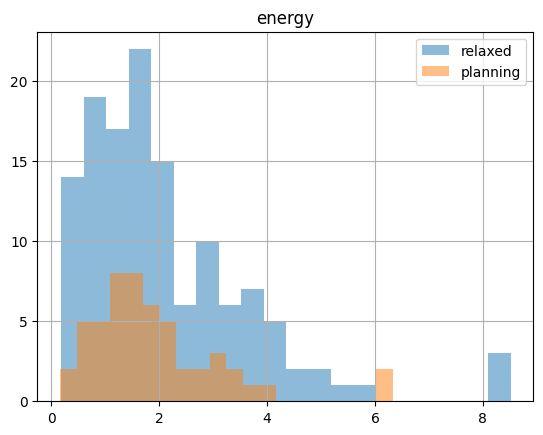

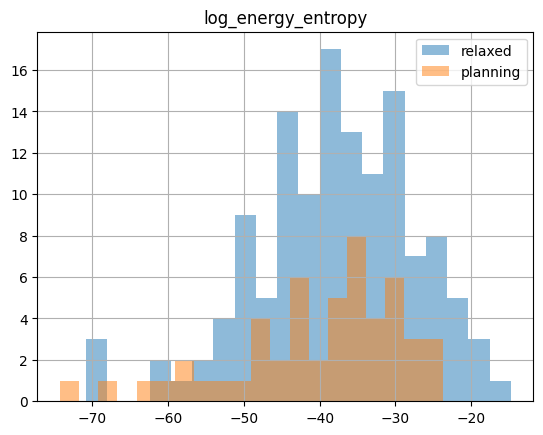

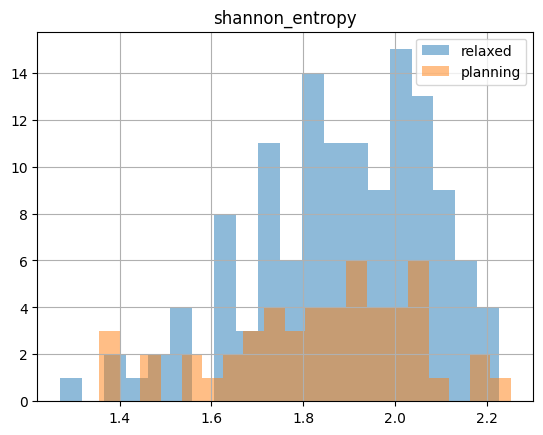

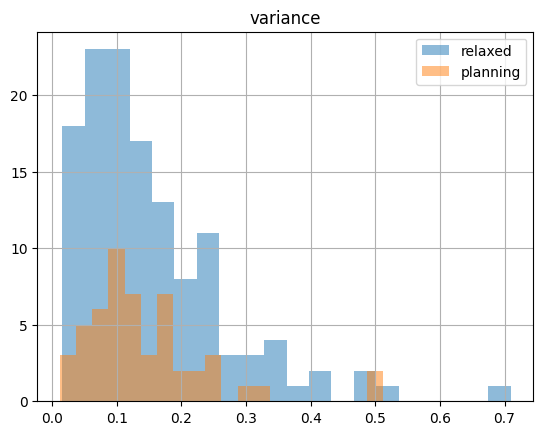

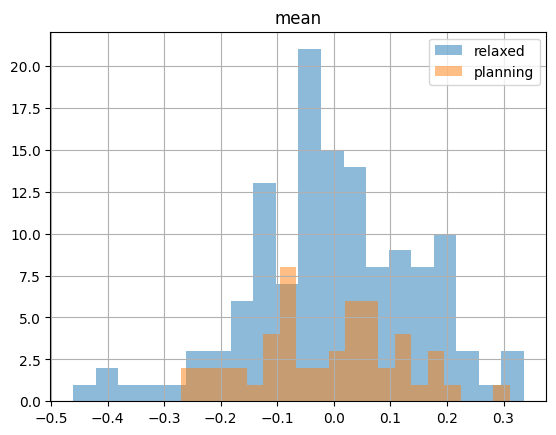

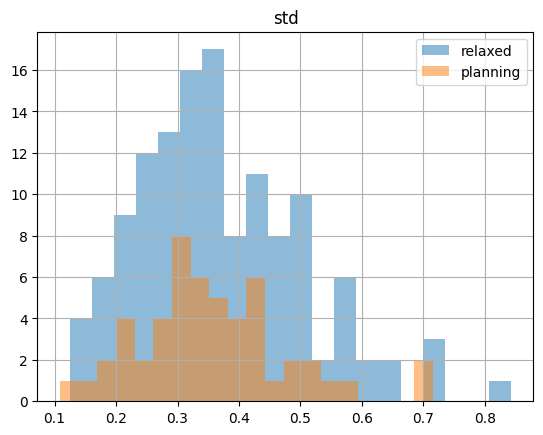

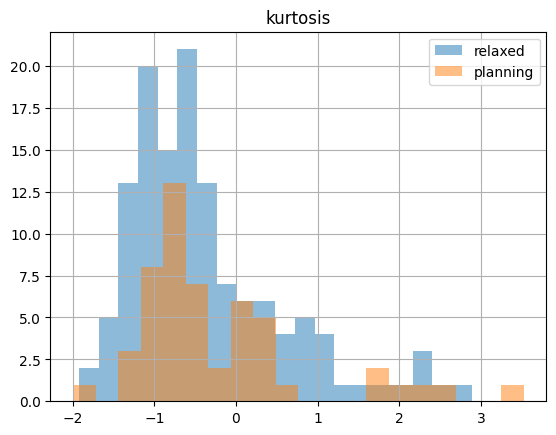

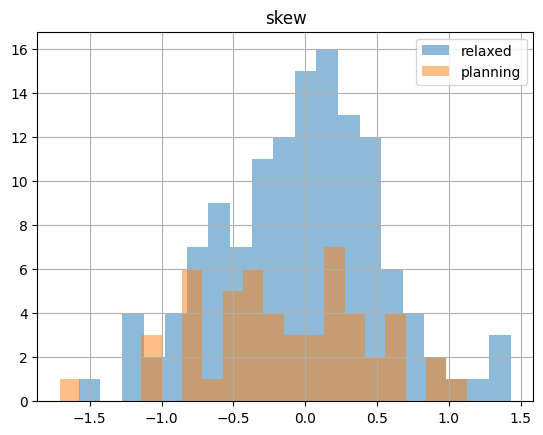

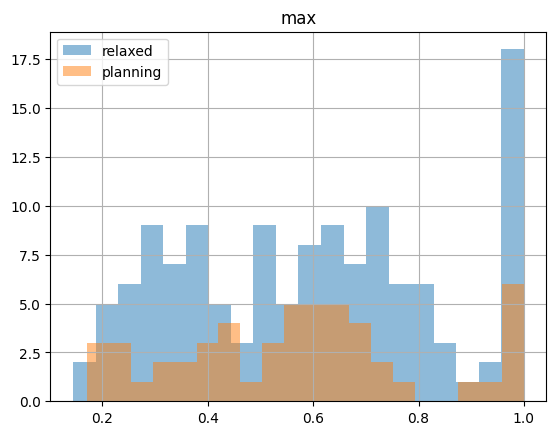

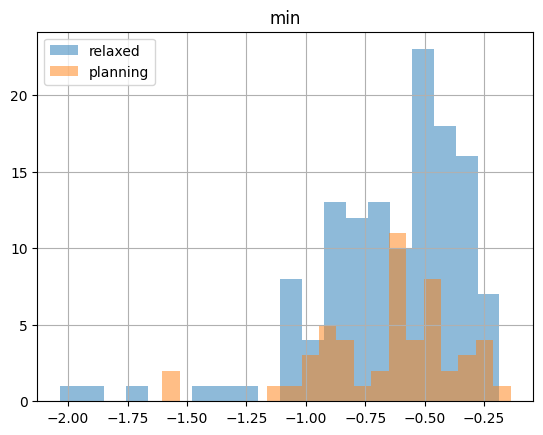

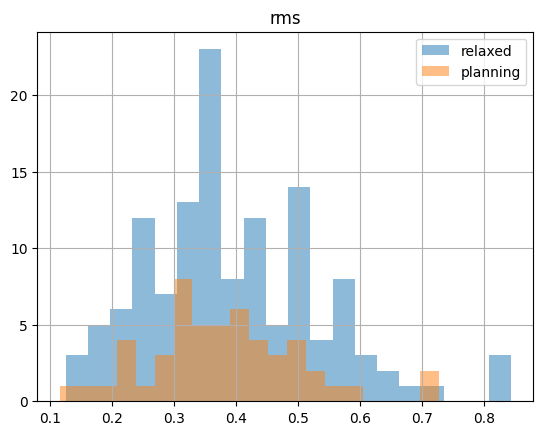

In [18]:
import matplotlib.pyplot as plt

for col in X_features.columns:
    plt.figure()
    X_features[y == 1][col].hist(alpha=0.5, label='relaxed', bins=20)
    X_features[y == 2][col].hist(alpha=0.5, label='planning', bins=20)
    plt.title(col)
    plt.legend()
    plt.show()

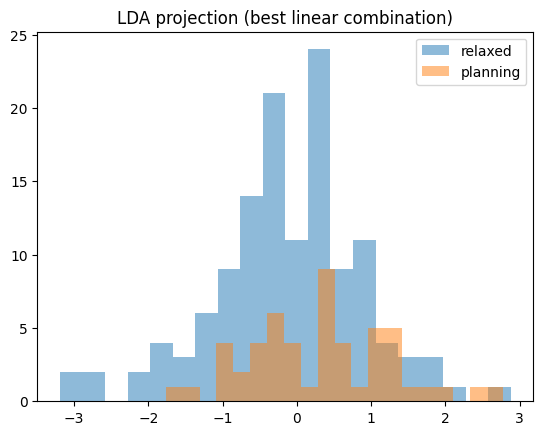

In [19]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X_features)
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

plt.figure()
plt.hist(X_lda[y==1], alpha=0.5, bins=20, label='relaxed')
plt.hist(X_lda[y==2], alpha=0.5, bins=20, label='planning')
plt.legend()
plt.title('LDA projection (best linear combination)')
plt.show()

In [21]:
import numpy as np
import pandas as pd
import pywt
from statsmodels.regression.linear_model import yule_walker

# ============================================================
# Assumes: raw_signals is a list/array of shape (n_trials, n_samples)
# i.e. raw_signals[i] is the full time-domain EEG epoch for trial i
# fs = sampling frequency in Hz
# ============================================================

fs = 256  # <-- set this to your actual sampling rate


# ---------------------------------------------
# 1. Hjorth Parameters
# ---------------------------------------------
def hjorth_params(signal):
    first_deriv = np.diff(signal)
    second_deriv = np.diff(first_deriv)

    var_zero = np.var(signal)
    var_d1 = np.var(first_deriv)
    var_d2 = np.var(second_deriv)

    activity = var_zero
    mobility = np.sqrt(var_d1 / var_zero) if var_zero > 0 else 0
    complexity = (np.sqrt(var_d2 / var_d1) / mobility) if (var_d1 > 0 and mobility > 0) else 0

    return activity, mobility, complexity


# ---------------------------------------------
# 2. Sample Entropy
# ---------------------------------------------
def sample_entropy(signal, m=2, r=None):
    """
    m: embedding dimension
    r: tolerance (typically 0.2 * std of signal)
    """
    signal = np.asarray(signal)
    N = len(signal)
    if r is None:
        r = 0.2 * np.std(signal)

    def _phi(m):
        templates = np.array([signal[i:i + m] for i in range(N - m + 1)])
        count = 0
        total = 0
        for i in range(len(templates)):
            dist = np.max(np.abs(templates - templates[i]), axis=1)
            count += np.sum(dist <= r) - 1  # exclude self-match
            total += len(templates) - 1
        return count / total if total > 0 else 0

    phi_m = _phi(m)
    phi_m1 = _phi(m + 1)

    if phi_m == 0 or phi_m1 == 0:
        return 0  # avoid log(0); handle degenerate case
    return -np.log(phi_m1 / phi_m)


# ---------------------------------------------
# 3. Autoregressive (AR) Coefficients
# ---------------------------------------------
def ar_coefficients(signal, order=6):
    """
    Fits an AR model of given order and returns the coefficients.
    """
    signal = np.asarray(signal) - np.mean(signal)  # remove DC offset
    rho, sigma = yule_walker(signal, order=order, method='mle')
    return rho  # array of length `order`


# ---------------------------------------------
# 4. Multi-band Wavelet Packet Energy
# ---------------------------------------------
def wpt_band_energy(signal, wavelet='db6', maxlevel=6):
    """
    Decomposes signal into full wavelet packet tree at maxlevel
    and returns energy of each node (i.e. energy per frequency band).
    """
    wp = pywt.WaveletPacket(data=signal, wavelet=wavelet, mode='symmetric', maxlevel=maxlevel)
    nodes = [node.path for node in wp.get_level(maxlevel, order='freq')]

    energies = {}
    total_energy = 0
    for node_path in nodes:
        coeffs = wp[node_path].data
        e = np.sum(coeffs ** 2)
        energies[f'wpt_energy_{node_path}'] = e
        total_energy += e

    # Also add relative (normalized) energy per node
    for node_path in nodes:
        energies[f'wpt_relenergy_{node_path}'] = (
            energies[f'wpt_energy_{node_path}'] / total_energy if total_energy > 0 else 0
        )

    return energies


# ---------------------------------------------
# 5. Band power ratios (using WPT band energies)
# ---------------------------------------------
def band_power_ratios(band_energies_dict, band_map):
    """
    band_map: dict mapping band name -> node_path, e.g.
              {'theta': 'aad', 'alpha': 'ada', 'beta': 'daa'}
    Adjust node paths based on your fs and maxlevel (check pywt frequency mapping).
    """
    ratios = {}
    bands = list(band_map.keys())
    for i in range(len(bands)):
        for j in range(i + 1, len(bands)):
            b1, b2 = bands[i], bands[j]
            e1 = band_energies_dict.get(f'wpt_energy_{band_map[b1]}', 0)
            e2 = band_energies_dict.get(f'wpt_energy_{band_map[b2]}', 0)
            ratios[f'ratio_{b1}_{b2}'] = e1 / e2 if e2 != 0 else 0
    return ratios


# ============================================================
# Master function: extract all features for one trial
# ============================================================
def extract_all_features(signal, fs=256, ar_order=6, wpt_wavelet='db6', wpt_level=6):
    features = {}

    # Hjorth
    activity, mobility, complexity = hjorth_params(signal)
    features['hjorth_activity'] = activity
    features['hjorth_mobility'] = mobility
    features['hjorth_complexity'] = complexity

    # Sample entropy
    features['sample_entropy'] = sample_entropy(signal)

    # AR coefficients
    ar_coefs = ar_coefficients(signal, order=ar_order)
    for i, c in enumerate(ar_coefs):
        features[f'ar_coef_{i+1}'] = c

    # Multi-band WPT energy (full tree at chosen level)
    wpt_energies = wpt_band_energy(signal, wavelet=wpt_wavelet, maxlevel=wpt_level)
    features.update(wpt_energies)

    return features


# ============================================================
# Apply across your dataset
# ============================================================
# raw_signals: shape (182, n_samples) -- one row per trial
# y: shape (182,) -- labels

feature_rows = [extract_all_features(sig, fs=fs) for sig in X]
X_all_features = pd.DataFrame(feature_rows)

print(X_all_features.shape)
print(X_all_features.head())

(182, 138)
   hjorth_activity  hjorth_mobility  hjorth_complexity  sample_entropy  \
0         0.042331         1.170131           1.275784             0.0   
1         0.059279         1.743326           1.079981             0.0   
2         0.162019         1.254355           1.314821             0.0   
3         0.235432         1.191728           1.232746             0.0   
4         0.052572         1.331197           1.134159             0.0   

   ar_coef_1  ar_coef_2  ar_coef_3  ar_coef_4  ar_coef_5  ar_coef_6  ...  \
0   0.330612  -0.141015  -0.254348  -0.080183   0.150815  -0.292464  ...   
1  -0.633616  -0.603229  -0.306551  -0.345547   0.038932  -0.053748  ...   
2   0.322000   0.017430  -0.685017   0.355354  -0.237156  -0.301814  ...   
3   0.407820  -0.450411  -0.155828   0.191665  -0.178278   0.094582  ...   
4  -0.256856  -0.426325  -0.277594  -0.382476  -0.483310  -0.243109  ...   

   wpt_relenergy_daddad  wpt_relenergy_daddaa  wpt_relenergy_daadaa  \
0              0

Original class counts: {1.0: 130, 2.0: 52}
Resampled class counts: {1.0: 130, 2.0: 130}


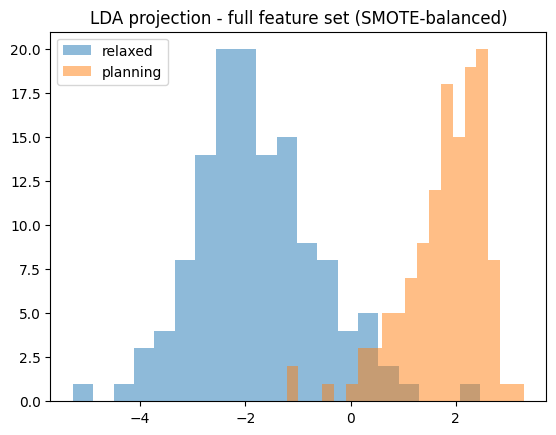

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

X_filled = X_all_features.fillna(0)

X_scaled = StandardScaler().fit_transform(X_filled)

smote = SMOTE(random_state=42, k_neighbors=3)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print("Original class counts:", pd.Series(y).value_counts().to_dict())
print("Resampled class counts:", pd.Series(y_resampled).value_counts().to_dict())

lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_resampled, y_resampled)

plt.figure()
plt.hist(X_lda[y_resampled==1], alpha=0.5, bins=20, label='relaxed')
plt.hist(X_lda[y_resampled==2], alpha=0.5, bins=20, label='planning')
plt.legend()
plt.title('LDA projection - full feature set (SMOTE-balanced)')
plt.show()

In [41]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

X_filled = X_all_features

pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=mutual_info_classif, k=15)),
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('lda', LinearDiscriminantAnalysis())
])

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
y_pred = cross_val_predict(pipe, X_filled, y, cv=skf)

print("Balanced accuracy:", balanced_accuracy_score(y, y_pred))
print(confusion_matrix(y, y_pred))
print(classification_report(y, y_pred, target_names=['relaxed', 'planning']))

Balanced accuracy: 0.46153846153846156
[[65 65]
 [30 22]]
              precision    recall  f1-score   support

     relaxed       0.68      0.50      0.58       130
    planning       0.25      0.42      0.32        52

    accuracy                           0.48       182
   macro avg       0.47      0.46      0.45       182
weighted avg       0.56      0.48      0.50       182



In [42]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

X_filled = X_all_features.fillna(0)

# ---------------------------------------------
# Basic SVM pipeline with feature selection + SMOTE
# ---------------------------------------------
pipe_svm = ImbPipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=mutual_info_classif, k=15)),  # cut 138 -> 15 features
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_svm = cross_val_predict(pipe_svm, X_filled, y, cv=skf)

print("Balanced accuracy (SVM):", balanced_accuracy_score(y, y_pred_svm))
print("\nConfusion matrix:\n", confusion_matrix(y, y_pred_svm))
print("\nClassification report:\n", classification_report(y, y_pred_svm, target_names=['relaxed', 'planning']))

Balanced accuracy (SVM): 0.48461538461538467

Confusion matrix:
 [[76 54]
 [32 20]]

Classification report:
               precision    recall  f1-score   support

     relaxed       0.70      0.58      0.64       130
    planning       0.27      0.38      0.32        52

    accuracy                           0.53       182
   macro avg       0.49      0.48      0.48       182
weighted avg       0.58      0.53      0.55       182



In [43]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.1, 1],
    'svm__kernel': ['rbf', 'linear']
}

inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(pipe_svm, param_grid, cv=inner_cv, scoring='balanced_accuracy', n_jobs=-1)

# Nested CV: outer loop gives honest performance, inner loop tunes hyperparameters
y_pred_svm_tuned = cross_val_predict(grid, X_filled, y, cv=outer_cv)

print("Balanced accuracy (tuned SVM, nested CV):", balanced_accuracy_score(y, y_pred_svm_tuned))
print(confusion_matrix(y, y_pred_svm_tuned))
print(classification_report(y, y_pred_svm_tuned, target_names=['relaxed', 'planning']))

Balanced accuracy (tuned SVM, nested CV): 0.49423076923076925
[[106  24]
 [ 43   9]]
              precision    recall  f1-score   support

     relaxed       0.71      0.82      0.76       130
    planning       0.27      0.17      0.21        52

    accuracy                           0.63       182
   macro avg       0.49      0.49      0.49       182
weighted avg       0.59      0.63      0.60       182

